# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [61]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

In [62]:
data = load_breast_cancer()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [63]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [65]:
df['benign_0__mal_1'] = data.target

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

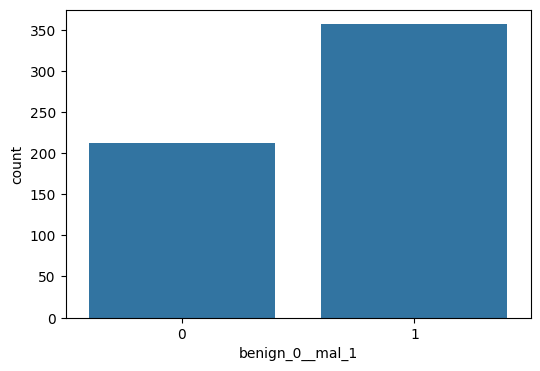

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x='benign_0__mal_1', data=df)
plt.show()

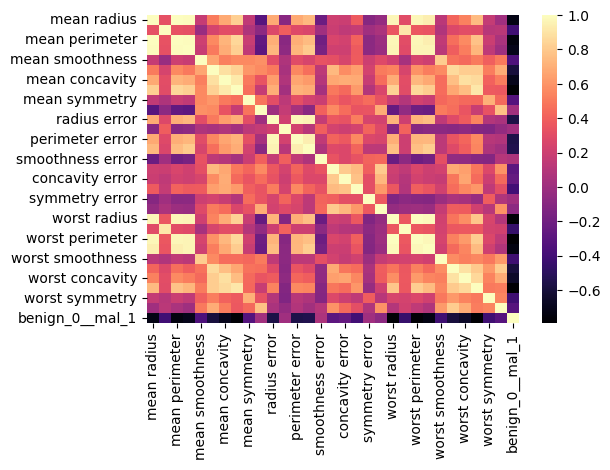

In [69]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), cmap='magma')
plt.show()

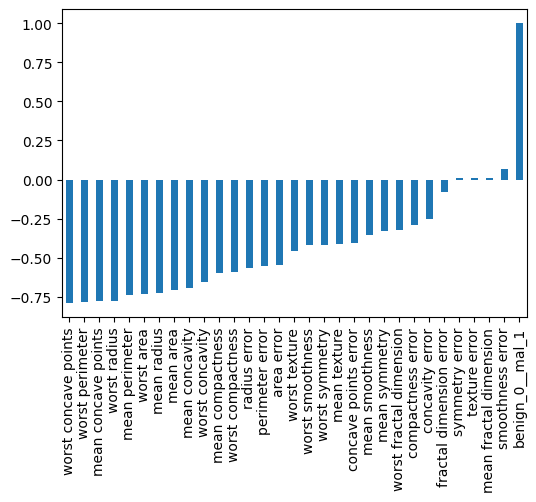

In [70]:
plt.figure(figsize=(6,4))
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')
plt.show()

## Train Test Split

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=101
)


## Scaling Data

In [74]:
from sklearn.preprocessing import MinMaxScaler

In [75]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model


In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [77]:
model = Sequential()

model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=15, activation='relu'))

model.add(Dense(units=1, activation='sigmoid'))

In [78]:
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training the Model

### Example One: Choosing too many epochs and overfitting!

In [79]:
model_1_history = model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test)
)


Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8047 - loss: 0.6480 - val_accuracy: 0.8741 - val_loss: 0.5994
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8523 - loss: 0.5885 - val_accuracy: 0.8811 - val_loss: 0.5499
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8758 - loss: 0.5385 - val_accuracy: 0.8951 - val_loss: 0.4994
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8844 - loss: 0.4860 - val_accuracy: 0.8881 - val_loss: 0.4439
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9045 - loss: 0.4412 - val_accuracy: 0.9021 - val_loss: 0.4020
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8995 - loss: 0.3937 - val_accuracy: 0.9231 - val_loss: 0.3544
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8921 - loss: 0.3671 - val_accuracy: 0.9371 - val_loss: 0.3165
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9297 - loss: 0.3046 - val_accuracy: 0.9441 - 

<Axes: >

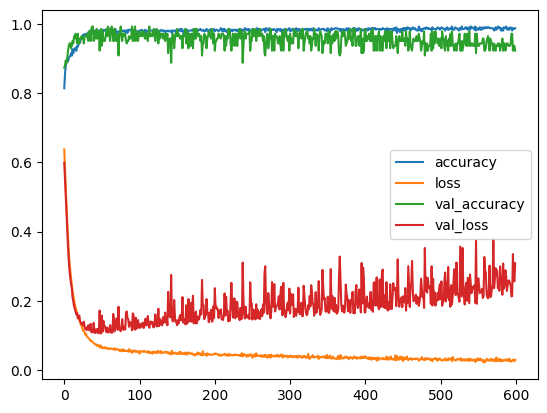

In [80]:
# model.history.history
model_loss = pd.DataFrame(model_1_history.history)
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [81]:
from tensorflow.keras.callbacks import EarlyStopping

In [82]:
model_2 = Sequential()

model_2.add(Dense(units=30, activation='relu'))
model_2.add(Dense(units=15, activation='relu'))
model_2.add(Dense(units=1, activation='sigmoid'))

model_2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=25
)

model_2_history = model_2.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.3884 - loss: 0.6938 - val_accuracy: 0.8392 - val_loss: 0.6481
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8232 - loss: 0.6327 - val_accuracy: 0.9510 - val_loss: 0.5895
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9183 - loss: 0.5727 - val_accuracy: 0.8881 - val_loss: 0.5347
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9142 - loss: 0.5179 - val_accuracy: 0.9720 - val_loss: 0.4797
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9162 - loss: 0.4595 - val_accuracy: 0.9510 - val_loss: 0.4352
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9132 - loss: 0.4251 - val_accuracy: 0.9371 - val_loss: 0.3894
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9172 - loss: 0.3893 - val_accuracy: 0.9510 - val_loss: 0.3475
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9247 - loss: 0.3408 - val_accuracy: 0.9231 - 

<Axes: >

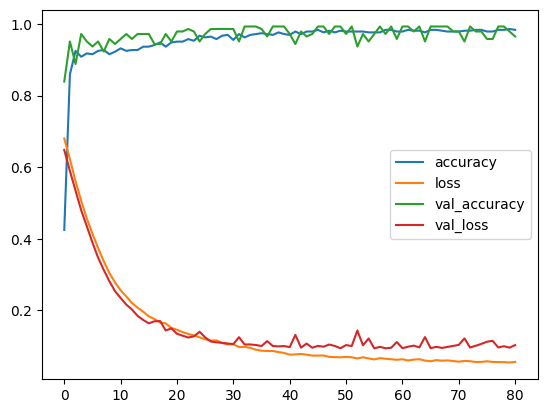

In [83]:
model_loss_2 = pd.DataFrame(model_2_history.history)
model_loss_2.plot()

## Example Three: Adding in DropOut Layers

In [84]:
from tensorflow.keras.layers import Dropout

In [85]:
model_3 = Sequential()

model_3.add(Dense(units=30, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=15, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=1, activation='sigmoid'))

model_3.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=25
)

model_3_history = model_3.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.5135 - loss: 0.6843 - val_accuracy: 0.7622 - val_loss: 0.6511
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5464 - loss: 0.6768 - val_accuracy: 0.8741 - val_loss: 0.6284
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5769 - loss: 0.6475 - val_accuracy: 0.8671 - val_loss: 0.6022
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6842 - loss: 0.6134 - val_accuracy: 0.8741 - val_loss: 0.5785
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7846 - loss: 0.6130 - val_accuracy: 0.8881 - val_loss: 0.5496
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7499 - loss: 0.5744 - val_accuracy: 0.9091 - val_loss: 0.5224
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7787 - loss: 0.5502 - val_accuracy: 0.8951 - val_loss: 0.4960
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7962 - loss: 0.5332 - val_accuracy: 0.9301 -

<Axes: >

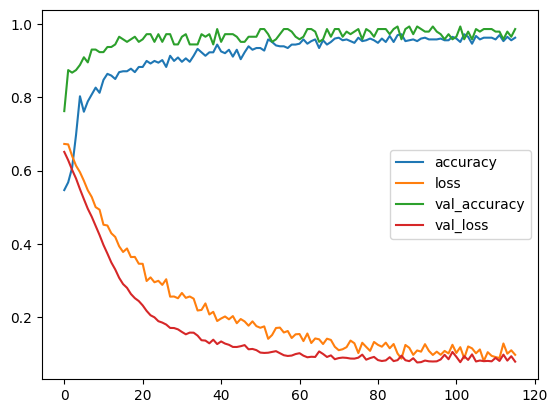

In [86]:
model_loss_3 = pd.DataFrame(model_3_history.history)
model_loss_3.plot()

# Model Evaluation

In [87]:
from sklearn.metrics import classification_report,confusion_matrix

In [93]:
predictions = (model_3.predict(X_test) > 0.5).astype("int32")

print("Model 3 - Early Stopping + Dropout")
print(classification_report(y_test, predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Model 3 - Early Stopping + Dropout
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        55
           1       0.98      1.00      0.99        88

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143



In [94]:
print(confusion_matrix(y_test, predictions))

[[53  2]
 [ 0 88]]


# save

In [95]:
import pickle

# save trained model
with open("model_weights.pkl", "wb") as f:
    pickle.dump(model_3, f)

# save scaler
with open("scaler_weights.pkl", "wb") as f:
    pickle.dump(scaler, f)